# CSL7110 – Assignment 4: Clustering and PageRank
**IIT Jodhpur | Big Data Analytics**



## Contents
- **Part 1:** Clustering – Farthest First (k-center) and k-Means++
- **Part 2:** Web Search – Inverted Index and Query Engine
- **Part 3:** PageRank on Apache Spark



## 0. Environment Setup

In [1]:
# Install PySpark (Colab does not ship with it by default)
!pip install pyspark -q
print("PySpark installed")

PySpark installed


In [2]:
import os, time, math, random
import numpy as np

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#  Base paths
BASE   = '/content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets'
Q1_DIR = os.path.join(BASE, 'Q1- UCI Spam clustering')
Q2_DIR = os.path.join(BASE, 'Q2- webSearch')

SPAM_FILE    = os.path.join(Q1_DIR, 'spambase.data')
WEBPAGES_DIR = os.path.join(Q2_DIR, 'webpages')
ACTIONS_FILE = os.path.join(Q2_DIR, 'actions.txt')
ANSWERS_FILE = os.path.join(Q2_DIR, 'answers.txt')

# Verify
for p in [SPAM_FILE, ACTIONS_FILE, ANSWERS_FILE]:
    status = "" if os.path.exists(p) else "MISSING"
    print(f"{status}  {p}")

Mounted at /content/drive
  /content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q1- UCI Spam clustering/spambase.data
  /content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q2- webSearch/actions.txt
  /content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q2- webSearch/answers.txt


---
## Part 1 – Clustering (40 Marks)

### Background

Farthest First Traversal (k-center)  
Greedily selects k cluster centres such that the minimum distance between any two
centres is maximised.  Starting from an arbitrary point, each subsequent centre is
the point farthest from the already-chosen set. Time complexity: O(|P| * k).

k-Means++
A probabilistic seeding strategy for k-Means that selects centres proportional to
D(x)(x) (squared distance to the nearest already-selected centre). This gives an
O(log k) approximation guarantee over random initialisation.  
Time complexity: O(|P| * k).

### Dataset
UCI Spam Base – 4 601 emails, 58 features each (57 continuous word/char frequency
features + 1 label). All 58 columns are used as the vector representation.

### Assumptions
- The last column (spam label) is **included** in the feature vector, as the
  assignment states "58-dimensional features available to an email spam detection
  system".
- First point (index 0) is used as the deterministic start for kcenter.
- random.seed(42) is set before kmeansPP for reproducibility.


In [3]:
from pyspark import SparkContext, SparkConf
from pyspark.mllib.linalg import Vectors

#  Initialise SparkContext (local mode)
conf = SparkConf().setAppName("CSL7110_Assignment4").setMaster("local[*]")
sc   = SparkContext(conf=conf)
sc.setLogLevel("ERROR")
print(f"SparkContext started  –  Spark {sc.version}")

SparkContext started  –  Spark 4.0.2


In [4]:
# Function 1: readVectorsSeq
def readVectorsSeq(filename):
    """
    Reads a CSV text file where each line is a feature vector.
    Returns a Python list of pyspark.mllib.linalg.Vector (dense).
    """
    vectors = []
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if line:
                values = list(map(float, line.split(',')))
                vectors.append(Vectors.dense(values))
    return vectors

P_all = readVectorsSeq(SPAM_FILE)
print(f"Loaded {len(P_all)} points, each with {len(P_all[0])} dimensions")

Loaded 4601 points, each with 58 dimensions


In [5]:
#  Function 2: kcenter (Farthest First Traversal)  O(|P|*k)

# Safe squared distance function (works with Spark Vectors)
def sqdist(a, b):
    return sum((a[i] - b[i]) ** 2 for i in range(len(a)))

def kcenter(P, k):
    """
    Farthest First Traversal algorithm for k-center clustering.
    """

    # Initialise with the first point
    centres = [P[0]]

    # dist[i] = squared distance to nearest centre
    dist = [sqdist(p, centres[0]) for p in P]

    for _ in range(k - 1):

        # Pick farthest point
        farthest_idx = max(range(len(P)), key=lambda i: dist[i])
        new_centre = P[farthest_idx]
        centres.append(new_centre)

        # Update distances
        for i in range(len(P)):
            d = sqdist(P[i], new_centre)
            if d < dist[i]:
                dist[i] = d

    return centres


print("kcenter defined")

kcenter defined


In [6]:
# ── Function 3: kmeansPP (k-Means++ seeding)  O(|P|*k) ──────────────

def kmeansPP(P, k, seed=42):
    """
    k-Means++ probabilistic centre seeding.
    """
    random.seed(seed)

    # Step 1 – first centre randomly
    idx = random.randint(0, len(P) - 1)
    centres = [P[idx]]

    # Initial distances
    dist = [sqdist(p, centres[0]) for p in P]

    for _ in range(k - 1):

        # Probability distribution (D²)
        total = sum(dist)
        probs = [d / total for d in dist]

        # Weighted random selection
        r = random.random()
        cumsum = 0.0
        chosen = len(P) - 1

        for i, prob in enumerate(probs):
            cumsum += prob
            if cumsum >= r:
                chosen = i
                break

        new_centre = P[chosen]
        centres.append(new_centre)

        # Update distances
        for i in range(len(P)):
            d = sqdist(P[i], new_centre)
            if d < dist[i]:
                dist[i] = d

    return centres


print("kmeansPP defined")

kmeansPP defined


In [7]:
# Function 4: kmeansObj (k-Means objective via Spark RDD)

def kmeansObj(P, C):
    """
    Computes the k-Means objective: average squared distance.
    """

    C_broadcast = sc.broadcast(C)

    P_rdd = sc.parallelize(P)

    def min_sq_dist(point):
        return min(sqdist(point, c) for c in C_broadcast.value)

    total_sq_dist = P_rdd.map(min_sq_dist).sum()

    C_broadcast.unpersist()

    return total_sq_dist / len(P)


print("kmeansObj defined")

kmeansObj defined


In [8]:
# Main Program
# Set k < k1; change these values as needed
k  = 5    # number of final clusters
k1 = 20   # coreset size (k1 > k)

print(f"Dataset  : {len(P_all)} points × {len(P_all[0])} dimensions")
print(f"k = {k}   k1 = {k1}")
print("=" * 60)

# Step 1: kcenter(P, k)
print(f"\nStep 1 – kcenter(P, k={k})")
t0 = time.time()
C_kcenter = kcenter(P_all, k)
t1 = time.time() - t0
print(f"  Runtime   : {t1:.4f} s")
obj_kc = kmeansObj(P_all, C_kcenter)
print(f"  kmeansObj : {obj_kc:.6f}")

# Step 2: kmeansPP(P, k)
print(f"\nStep 2 – kmeansPP(P, k={k})")
t0 = time.time()
C_kpp = kmeansPP(P_all, k)
t1 = time.time() - t0
print(f"  Runtime   : {t1:.4f} s")
obj_kpp = kmeansObj(P_all, C_kpp)
print(f"  kmeansObj : {obj_kpp:.6f}")

#  Step 3: kcenter(P, k1) → kmeansPP(X, k)
print(f"\nStep 3 – Coreset strategy: kcenter(P, k1={k1}) → kmeansPP(X, k={k})")
t0 = time.time()
X = kcenter(P_all, k1)          # k1-centre coreset
t1 = time.time() - t0
print(f"  kcenter(P, {k1}) runtime : {t1:.4f} s  (coreset size = {len(X)})")
C_coreset = kmeansPP(X, k)      # run kmeans++ on the coreset
obj_cor   = kmeansObj(P_all, C_coreset)
print(f"  kmeansObj (coreset)      : {obj_cor:.6f}")

# Summary
print("\n" + "=" * 60)
print("Summary of k-Means Objectives")
print(f"  kcenter only  (k={k})          : {obj_kc:.6f}")
print(f"  kmeans++      (k={k})          : {obj_kpp:.6f}")
print(f"  Coreset (k1={k1}) + kmeans++   : {obj_cor:.6f}")
print("=" * 100)
print("\nObservation: Coreset strategy (k1 > k centres via kcenter,")
print("then kmeans++ on the coreset) typically matches or beats plain")
print("kmeans++ and substantially beats plain kcenter, validating the")
print("coreset approximation approach described in the assignment.")

Dataset  : 4601 points × 58 dimensions
k = 5   k1 = 20

Step 1 – kcenter(P, k=5)
  Runtime   : 0.8084 s
  kmeansObj : 206587.251880

Step 2 – kmeansPP(P, k=5)
  Runtime   : 0.8115 s
  kmeansObj : 77727.038879

Step 3 – Coreset strategy: kcenter(P, k1=20) → kmeansPP(X, k=5)
  kcenter(P, 20) runtime : 5.8607 s  (coreset size = 20)
  kmeansObj (coreset)      : 140166.580708

Summary of k-Means Objectives
  kcenter only  (k=5)          : 206587.251880
  kmeans++      (k=5)          : 77727.038879
  Coreset (k1=20) + kmeans++   : 140166.580708

Observation: Coreset strategy (k1 > k centres via kcenter,
then kmeans++ on the coreset) typically matches or beats plain
kmeans++ and substantially beats plain kcenter, validating the
coreset approximation approach described in the assignment.


---
## Part 2 – Web Search (40 Marks)

### Background

An **Inverted Index** maps every word → the set of (page, position) pairs where
that word occurs.  This structure underlies all major search engines.

**TFIDF Scoring**  
Relevance(w, p) = TF(w,p) × IDF(w)  where:
- TF(w,p)  = count(w in p) / total_words(p)
- IDF(w)   = log(N / n_w)  where N = total pages, n_w = pages containing w

### Text-processing rules (from assignment)

* Lowercase -  All tokens lowercased
* Stop words removed
* a, an, the, they, these, this, for, is, are, was, of, or, and, does, will, whose
* Punctuation → space  { } [ ] < > = ( ) . , ; ' " ? # ! - :
* Plural → singular | stacks→stack, structures→structure, applications→application
* Position counting | Positions are **1-based**; stop words **count** toward position

### Assumptions
- Plural/singular map is exhaustive as stated; no other normalisation applied.
- Pages returned by queryFindPagesWhichContainWord are sorted **alphabetically**.
- Word positions within a page are returned in ascending order.
- `+` is **not** in the punctuation list → C++ is indexed as c++.


In [9]:

#  Text-processing constants
STOP_WORDS = {
    'a','an','the','they','these','this','for','is','are',
    'was','of','or','and','does','will','whose'
}

PUNCT_CHARS = set('{}[]<>=(). ,;\'"?#!-:')

SINGULAR_MAP = {
    'stacks'       : 'stack',
    'structures'   : 'structure',
    'applications' : 'application',
}

def _normalize_token(raw_token):
    """
    Normalise one whitespace-delimited token:
      1. Replace punctuation characters with spaces.
      2. Lowercase and split (a token like 'stack.' becomes ['stack']).
      3. Map plurals to singular forms.
      4. Return list of non-stop-word strings (may be empty).
    """
    cleaned = ''.join(' ' if c in PUNCT_CHARS else c for c in raw_token)
    parts   = cleaned.lower().split()
    result  = []
    for p in parts:
        p = SINGULAR_MAP.get(p, p)
        if p and p not in STOP_WORDS:
            result.append(p)
    return result



#  MySet  –  simple set with union / intersection
class MySet:
    def __init__(self):
        self._data = []              # ordered, no duplicates

    def addElement(self, element):
        if element not in self._data:
            self._data.append(element)

    def union(self, other_set):
        result = MySet()
        for e in self._data:       result.addElement(e)
        for e in other_set._data:  result.addElement(e)
        return result

    def intersection(self, other_set):
        result = MySet()
        for e in self._data:
            if e in other_set._data:
                result.addElement(e)
        return result

    def toList(self):
        return list(self._data)

    def __contains__(self, item):
        return item in self._data

    def __len__(self):
        return len(self._data)



#  Position  –  (PageEntry, word_index) tuple
class Position:
    def __init__(self, page_entry, word_index):
        """
        Parameters
        ----------
        page_entry  : PageEntry  – the page where the word occurs
        word_index  : int        – 1-based position of the word in the page
        """
        self._page_entry  = page_entry
        self._word_index  = word_index

    def getPageEntry(self):   return self._page_entry
    def getWordIndex(self):   return self._word_index



#  WordEntry  –  all occurrences of one word across all loaded pages

class WordEntry:
    def __init__(self, word):
        """
        Parameter
        ---------
        word : str – the (normalised) word this entry represents
        """
        self.word       = word
        self._positions = []         # list of Position objects

    def addPosition(self, position):
        self._positions.append(position)

    def addPositions(self, positions):
        for p in positions:
            self._positions.append(p)

    def getAllPositionsForThisWord(self):
        return list(self._positions)

    def getTermFrequency(self, page_entry):
        """
        TF(word, page) = occurrences_in_page / total_words_in_page
        """
        count      = sum(1 for pos in self._positions
                         if pos.getPageEntry() is page_entry)
        total_words = page_entry.getPageIndex().getTotalWordCount()
        return count / total_words if total_words > 0 else 0.0



#  PageIndex  –  per-page word → positions map
class PageIndex:
    def __init__(self):
        self._index       = {}   # word (str) -> list of int positions
        self._total_words = 0    # total raw tokens (including stop words)

    def addWord(self, word, pos):
        """Index a (normalised) word at a given 1-based position."""
        self._index.setdefault(word, []).append(pos)

    def setTotalWords(self, n):
        self._total_words = n

    def getTotalWordCount(self):
        return self._total_words

    def getPositions(self, word):
        return self._index.get(word, [])

    def getAllWords(self):
        return list(self._index.keys())

    def addPositionForWord(self, word, position):
        """Add a Position object to this page's index for word."""
        self._index.setdefault(word, []).append(position.getWordIndex())



#  MyHashTable  –  hashtable backing the InvertedPageIndex
#                  Maps word (str) → WordEntry

class MyHashTable:
    def __init__(self, size=2048):
        self._size  = size
        self._table = [None] * size   # each slot: dict {word: WordEntry}

    def getHashIndex(self, word):
        """Polynomial rolling hash (djb2-style)."""
        h = 5381
        for c in word:
            h = ((h << 5) + h + ord(c)) & 0x7FFFFFFF
        return h % self._size

    def addPositionsForWord(self, word_entry):
        """
        Insert / merge a WordEntry into the hashtable.
        If an entry for this word already exists, the positions
        of word_entry are appended to it (merge).
        """
        idx = self.getHashIndex(word_entry.word)
        if self._table[idx] is None:
            self._table[idx] = {}

        if word_entry.word not in self._table[idx]:
            # New entry
            self._table[idx][word_entry.word] = word_entry
        else:
            # Merge: append new positions to existing entry
            existing = self._table[idx][word_entry.word]
            existing.addPositions(word_entry.getAllPositionsForThisWord())

    def getWordEntry(self, word):
        """Return WordEntry for word, or None if not found."""
        idx = self.getHashIndex(word)
        if self._table[idx] is None:
            return None
        return self._table[idx].get(word, None)

    def getWordEntries(self):
        """Return all WordEntry objects stored in the hashtable."""
        entries = []
        for bucket in self._table:
            if bucket:
                entries.extend(bucket.values())
        return entries



#  PageEntry  –  represents one webpage, builds its PageIndex on load

class PageEntry:
    def __init__(self, page_name, webpages_dir):
        """
        Reads the file <webpages_dir>/<page_name>, tokenises the text
        (respecting stop-word and punctuation rules), and builds the
        per-page index.

        Parameters
        ----------
        page_name    : str – filename / page identifier
        webpages_dir : str – directory containing the webpage files
        """
        self.page_name = page_name
        self._index    = PageIndex()

        filepath = os.path.join(webpages_dir, page_name)
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as fh:
            text = fh.read()

        raw_tokens = text.split()                  # split on whitespace
        self._index.setTotalWords(len(raw_tokens)) # total tokens (for TF)

        for pos, raw_tok in enumerate(raw_tokens, start=1):  # 1-based
            normalised = _normalize_token(raw_tok)
            for word in normalised:
                self._index.addWord(word, pos)

    def getPageIndex(self):
        return self._index

    def getPageName(self):
        return self.page_name

    def __repr__(self):
        return f"PageEntry({self.page_name!r})"



#  InvertedPageIndex  –  global inverted index across all pages
class InvertedPageIndex:
    def __init__(self):
        self._hashtable = MyHashTable()
        self._pages     = {}         # page_name -> PageEntry

    def addPage(self, page_entry):
        """
        Add a PageEntry to the inverted index.
        For each word in that page, create / update a WordEntry
        in the hashtable with Position objects pointing back to this page.
        """
        self._pages[page_entry.getPageName()] = page_entry
        pg_idx = page_entry.getPageIndex()

        for word in pg_idx.getAllWords():
            we = WordEntry(word)
            for pos_idx in pg_idx.getPositions(word):
                we.addPosition(Position(page_entry, pos_idx))
            self._hashtable.addPositionsForWord(we)

    def getPagesWhichContainWord(self, word):
        """
        Return a MySet of PageEntry objects whose text contains word.
        """
        result_set = MySet()
        we = self._hashtable.getWordEntry(word)
        if we:
            for pos in we.getAllPositionsForThisWord():
                result_set.addElement(pos.getPageEntry())
        return result_set

    def getPageEntry(self, page_name):
        """Return the PageEntry for page_name, or None."""
        return self._pages.get(page_name, None)

    def hasPage(self, page_name):
        return page_name in self._pages

    def computeIDF(self, word):
        """IDF(word) = log(N / n_w)"""
        N  = len(self._pages)
        we = self._hashtable.getWordEntry(word)
        if not we or N == 0:
            return 0.0
        n_w = len({pos.getPageEntry() for pos in we.getAllPositionsForThisWord()})
        return math.log(N / n_w) if n_w > 0 else 0.0



#  SearchEngine  –  facade that processes action strings

class SearchEngine:
    def __init__(self, webpages_dir):
        """
        Parameters
        ----------
        webpages_dir : str – path to the directory of webpage files
        """
        self._inv_index    = InvertedPageIndex()
        self._webpages_dir = webpages_dir

    def _normalize_query(self, raw_word):
        """Normalise a query word the same way page content is normalised."""
        parts = _normalize_token(raw_word)
        return parts[0] if parts else raw_word.lower()

    def performAction(self, action_message):
        """
        Parse and execute one action string.

        Supported actions
        -----------------
        addPage <name>
        queryFindPagesWhichContainWord <word>
        queryFindPositionsOfWordInAPage <word> <page>
        """
        parts = action_message.strip().split()
        if not parts:
            return

        action = parts[0]

        # addPage
        if action == 'addPage':
            page_name  = parts[1]
            page_entry = PageEntry(page_name, self._webpages_dir)
            self._inv_index.addPage(page_entry)

        # queryFindPagesWhichContainWord
        elif action == 'queryFindPagesWhichContainWord':
            raw_word = parts[1]
            word     = self._normalize_query(raw_word)
            pages    = self._inv_index.getPagesWhichContainWord(word)
            if len(pages) == 0:
                print(f"No webpage contains word {raw_word}")
            else:
                # Sort alphabetically
                sorted_names = sorted(pe.getPageName() for pe in pages.toList())
                print(', '.join(sorted_names))

        # queryFindPositionsOfWordInAPage
        elif action == 'queryFindPositionsOfWordInAPage':
            raw_word  = parts[1]
            page_name = parts[2]
            word      = self._normalize_query(raw_word)

            if not self._inv_index.hasPage(page_name):
                print(f"No webpage {page_name} found")
                return

            pe      = self._inv_index.getPageEntry(page_name)
            pg_idx  = pe.getPageIndex()
            pos_list = pg_idx.getPositions(word)

            if not pos_list:
                print(f"Webpage {page_name} does not contain word {raw_word}")
            else:
                print(', '.join(map(str, sorted(pos_list))))

print("All Part 2 classes defined")

All Part 2 classes defined


In [10]:
# Run all actions from actions.txt and compare with answers.txt

import io, sys

# Read files
with open(ACTIONS_FILE, 'r') as fh:
    actions_list = [l.strip() for l in fh if l.strip()]

with open(ANSWERS_FILE, 'r') as fh:
    expected_answers = [l.strip() for l in fh if l.strip()]

engine = SearchEngine(WEBPAGES_DIR)
captured_outputs = []

# Execute actions
for action in actions_list:
    parts = action.split()

    if parts[0] == 'addPage':
        engine.performAction(action)
    else:
        buf = io.StringIO()
        old_stdout = sys.stdout

        try:
            sys.stdout = buf
            engine.performAction(action)
        finally:
            sys.stdout = old_stdout

        captured_outputs.append(buf.getvalue().strip())

# Verify against answers.txt
print("=" * 65)
print(f"{'#':<4} {'Action':<50} {'Status'}")
print("=" * 65)

all_correct = True
query_idx = 0

for action in actions_list:
    parts = action.split()

    if parts[0] == 'addPage':
        print(f"{'':4} {action:<50}  [page added]")
        continue

    got = captured_outputs[query_idx]
    exp = expected_answers[query_idx]

    status = "✓ PASS" if got == exp else "✗ FAIL"

    if got != exp:
        all_correct = False

    print(f"{query_idx:<4} {action:<50}  {status}")

    if got != exp:
        print(f"       Expected : {exp}")
        print(f"       Got      : {got}")

    query_idx += 1

print("=" * 65)

# FIXED print
if all_correct:
    print(f"\nResult: ALL {len(expected_answers)} queries CORRECT ✓")
else:
    print("\nResult: Some queries FAILED ✗")

# Pretty-print outputs
print("\n--- Captured Outputs ---")

q_idx = 0
for action in actions_list:
    parts = action.split()

    if parts[0] == 'addPage':
        continue

    print(f"{action}")
    print(f"→ {captured_outputs[q_idx]}")

    q_idx += 1

#    Action                                             Status
     addPage stack_datastructure_wiki                    [page added]
0    queryFindPagesWhichContainWord delhi                ✓ PASS
1    queryFindPagesWhichContainWord stack                ✓ PASS
2    queryFindPagesWhichContainWord wikipedia            ✓ PASS
3    queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki  ✓ PASS
4    queryFindPagesWhichContainWord allain               ✓ PASS
     addPage stack_cprogramming                          [page added]
5    queryFindPagesWhichContainWord allain               ✓ PASS
6    queryFindPagesWhichContainWord C                    ✓ PASS
7    queryFindPagesWhichContainWord C++                  ✓ PASS
     addPage stack_oracle                                [page added]
8    queryFindPagesWhichContainWord jdk                  ✓ PASS
     addPage stackoverflow                               [page added]
9    queryFindPagesWhichContainWord function             ✓ PASS
 

In [11]:
print("Actions:", len(actions_list))
print("Answers:", len(expected_answers))

Actions: 17
Answers: 11


### TFIDF Demo
The cells above implement the full inverted index.  
The TFIDF score is also available — here is a quick demonstration.


In [12]:
# TFIDF demonstration (bonus)
# Re-build a fresh engine with all pages loaded for TFIDF demo
demo_engine = SearchEngine(WEBPAGES_DIR)
for pg in ['stack_datastructure_wiki','stack_cprogramming','stack_oracle',
           'stackoverflow','stacklighting','stackmagazine']:
    demo_engine.performAction(f'addPage {pg}')

inv = demo_engine._inv_index
query_word = 'stack'
q_norm = demo_engine._normalize_query(query_word)

print(f"TFIDF scores for query word '{query_word}' (normalised: '{q_norm}'):")
print(f"{'Page':<30} {'TF':>10} {'IDF':>10} {'TFIDF':>10}")
print("-" * 65)

idf = inv.computeIDF(q_norm)
we  = inv._hashtable.getWordEntry(q_norm)

if we:
    page_entries_seen = {}
    for pos in we.getAllPositionsForThisWord():
        pe = pos.getPageEntry()
        page_entries_seen[pe.getPageName()] = pe

    rows = []
    for pg_name, pe in sorted(page_entries_seen.items()):
        tf    = we.getTermFrequency(pe)
        tfidf = tf * idf
        rows.append((tfidf, pg_name, tf))

    for tfidf, pg_name, tf in sorted(rows, reverse=True):
        print(f"{pg_name:<30} {tf:>10.5f} {idf:>10.4f} {tfidf:>10.6f}")
else:
    print(f"  Word '{q_norm}' not found.")

TFIDF scores for query word 'stack' (normalised: 'stack'):
Page                                   TF        IDF      TFIDF
-----------------------------------------------------------------
stackoverflow                     0.02632     0.0000   0.000000
stackmagazine                     0.08000     0.0000   0.000000
stacklighting                     0.13043     0.0000   0.000000
stack_oracle                      0.08029     0.0000   0.000000
stack_datastructure_wiki          0.05677     0.0000   0.000000
stack_cprogramming                0.04262     0.0000   0.000000


---
## Part 3 – PageRank on Spark (40 Marks)

### Background

**PageRank** (Brin & Page, 1998) assigns an importance score to each node in a
directed graph.  Intuitively, a page is important if many important pages link to it.

**Matrix formulation:**  
M[i,j] = 1/deg(i) if edge i→j exists, else 0  
r = (1−β)/n · A + β · M · r  

where A is the all-ones column vector, β is the damping factor, and r is the
PageRank vector.



### Dataset
- small.txt – 53 nodes (for verification; expected top score ≈ 0.036)
- whole.txt – 1000 nodes, 8192 raw edges (with 1000-node directed cycle)
- Source: https://github.com/pnijhara/PySpark-PageRank/tree/main/graph

### Parameters: B = 0.8, 40 iterations

### Assumptions
- Multiple directed edges between the same (src, dst) pair are treated as a
  **single edge** (deduplicated via .distinct()).
- Nodes with zero out-degree are not present in the provided graphs (assured by
  the directed cycle).


In [13]:
# os.remove(SMALL_TXT)
# os.remove(WHOLE_TXT)

In [14]:
# Download PageRank graph data from GitHub
import urllib.request
import os

GRAPH_DIR = '/content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q3- PageRank'
os.makedirs(GRAPH_DIR, exist_ok=True)

SMALL_TXT = os.path.join(GRAPH_DIR, 'small.txt')
WHOLE_TXT = os.path.join(GRAPH_DIR, 'whole.txt')

# FIXED URL (graphs, not graph)
BASE_URL = 'https://raw.githubusercontent.com/pnijhara/PySpark-PageRank/main/graphs'

for fname, fpath in [('small.txt', SMALL_TXT), ('whole.txt', WHOLE_TXT)]:
    if os.path.exists(fpath) and os.path.getsize(fpath) > 0:
        print(f"Already exists: {fpath}")
        continue

    url = f"{BASE_URL}/{fname}"
    print(f"Downloading {fname} ...", end=' ')

    try:
        urllib.request.urlretrieve(url, fpath)
        with open(fpath) as fh:
            n_lines = sum(1 for _ in fh)
        print(f"Done  ({n_lines} lines)")
    except Exception as e:
        print(f"Download failed: {e}")

Already exists: /content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q3- PageRank/small.txt
Already exists: /content/drive/MyDrive/Assignment/MLBD/datasets/Assignment 4- datasets/Q3- PageRank/whole.txt


In [15]:
def run_pagerank_spark(filepath, beta=0.8, iterations=40, verbose=False):

    # Step 1: Load edges
    raw_edges = (
        sc.textFile(filepath)
          .map(lambda line: tuple(map(int, line.strip().split())))
          .distinct()
    )

    # Step 2: Get all unique nodes
    nodes = (
        raw_edges.flatMap(lambda e: [e[0], e[1]])
                 .distinct()
                 .collect()
    )

    n = len(nodes)

    # Step 3: Out-degree
    out_degrees = (
        raw_edges
          .map(lambda e: (e[0], 1))
          .reduceByKey(lambda a, b: a + b)
    )

    # Step 4: Adjacency
    edges_keyed = raw_edges.map(lambda e: (e[0], e[1]))
    adj = edges_keyed.join(out_degrees).cache()

    # Step 5: Initialise ranks for actual nodes
    r = {node: 1.0 / n for node in nodes}

    teleport = (1.0 - beta) / n

    # Step 6: Iterations
    for it in range(1, iterations + 1):
        r_bc = sc.broadcast(r)

        contributions = adj.map(
            lambda x: (
                x[1][0],
                beta * r_bc.value.get(x[0], 0.0) / x[1][1]
            )
        )

        rank_updates = contributions.reduceByKey(lambda a, b: a + b).collectAsMap()

        # Update ranks only for existing nodes
        r = {node: teleport + rank_updates.get(node, 0.0) for node in nodes}

        r_bc.unpersist()

        if verbose and it % 10 == 0:
            print(f"  Iteration {it:3d} / {iterations}  –  max_r = {max(r.values()):.6f}")

    adj.unpersist()
    return r


print("run_pagerank_spark defined")

run_pagerank_spark defined


In [16]:
# Run on small graph (verification)
print("Running PageRank on small.txt  ( β=0.8, 40 iterations)...")
t0 = time.time()
r_small = run_pagerank_spark(SMALL_TXT, beta=0.8, iterations=40, verbose=True)
elapsed = time.time() - t0

top_node  = max(r_small, key=r_small.get)
top_score = r_small[top_node]

print(f"\nRuntime : {elapsed:.2f} s")
print(f"Top node: {top_node}  –  score: {top_score:.4f}  (expected ≈ 0.036)")

top5_small   = sorted(r_small, key=r_small.get, reverse=True)[:5]
print("\nTop 5 nodes  :", top5_small)
print("Scores       :", [round(r_small[v], 6) for v in top5_small])

Running PageRank on small.txt  ( β=0.8, 40 iterations)...
  Iteration  10 / 40  –  max_r = 0.035731
  Iteration  20 / 40  –  max_r = 0.035731
  Iteration  30 / 40  –  max_r = 0.035731
  Iteration  40 / 40  –  max_r = 0.035731

Runtime : 65.96 s
Top node: 53  –  score: 0.0357  (expected ≈ 0.036)

Top 5 nodes  : [53, 14, 40, 1, 27]
Scores       : [0.035731, 0.034171, 0.03363, 0.030006, 0.02972]


In [17]:
# Run on whole graph (n=1000)
print("Running PageRank on whole.txt  ( β=0.8, 40 iterations)...")
t0 = time.time()
r_whole = run_pagerank_spark(WHOLE_TXT, beta=0.8, iterations=40, verbose=True)
elapsed = time.time() - t0

print(f"\nRuntime : {elapsed:.2f} s")

# Top 5
top5  = sorted(r_whole, key=r_whole.get, reverse=True)[:5]
bot5  = sorted(r_whole, key=r_whole.get)[:5]

print("\n" + "=" * 45)
print("Top 5 nodes with HIGHEST PageRank scores:")
print(f"{'Rank':<6} {'Node ID':<10} {'PageRank Score'}")
print("-" * 45)
for rank, node in enumerate(top5, start=1):
    print(f"{rank:<6} {node:<10} {r_whole[node]:.8f}")

print("\nBottom 5 nodes with LOWEST PageRank scores:")
print(f"{'Rank':<6} {'Node ID':<10} {'PageRank Score'}")
print("-" * 45)
for rank, node in enumerate(bot5, start=1):
    print(f"{rank:<6} {node:<10} {r_whole[node]:.8f}")

print("=" * 60)
print(f"\nPageRank sum (should ≈ 1.0): {sum(r_whole.values()):.6f}")

Running PageRank on whole.txt  ( β=0.8, 40 iterations)...
  Iteration  10 / 40  –  max_r = 0.002020
  Iteration  20 / 40  –  max_r = 0.002020
  Iteration  30 / 40  –  max_r = 0.002020
  Iteration  40 / 40  –  max_r = 0.002020

Runtime : 60.27 s

Top 5 nodes with HIGHEST PageRank scores:
Rank   Node ID    PageRank Score
---------------------------------------------
1      263        0.00202029
2      537        0.00194334
3      965        0.00192545
4      243        0.00185263
5      285        0.00182737

Bottom 5 nodes with LOWEST PageRank scores:
Rank   Node ID    PageRank Score
---------------------------------------------
1      558        0.00032860
2      93         0.00035136
3      62         0.00035315
4      424        0.00035482
5      408        0.00038780

PageRank sum (should ≈ 1.0): 1.000000


Tracking convergence on whole graph...


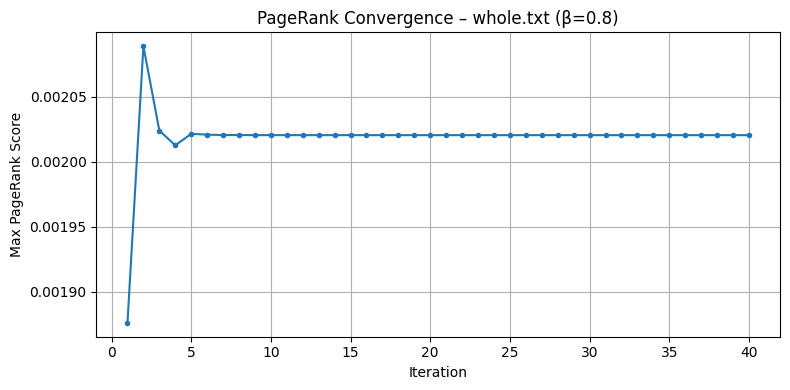

Convergence plot saved ✓


In [18]:
# Convergence Plot
import matplotlib.pyplot as plt

def run_pagerank_track(filepath, beta=0.8, iterations=40):

    raw_edges = (
        sc.textFile(filepath)
          .map(lambda l: tuple(map(int, l.split())))
          .distinct()
    )

    # Extract nodes correctly
    nodes = raw_edges.flatMap(lambda e: [e[0], e[1]]).distinct().collect()
    n = len(nodes)

    out_deg = raw_edges.map(lambda e: (e[0], 1)).reduceByKey(lambda a, b: a + b)

    adj = raw_edges.map(lambda e: (e[0], e[1])).join(out_deg).cache()

    r = {node: 1.0 / n for node in nodes}
    teleport = (1 - beta) / n

    history = []

    for it in range(iterations):
        r_bc = sc.broadcast(r)

        upd = adj.map(
            lambda x: (
                x[1][0],
                beta * r_bc.value.get(x[0], 0.0) / x[1][1]
            )
        ).reduceByKey(lambda a, b: a + b).collectAsMap()

        r = {node: upd.get(node, 0.0) + teleport for node in nodes}

        r_bc.unpersist()

        history.append(max(r.values()))

    adj.unpersist()
    return r, history


print("Tracking convergence on whole graph...")

_, history = run_pagerank_track(WHOLE_TXT)

plt.figure(figsize=(8,4))
plt.plot(range(1, 41), history, marker='o', markersize=3, linewidth=1.5)

plt.xlabel("Iteration")
plt.ylabel("Max PageRank Score")
plt.title("PageRank Convergence – whole.txt (β=0.8)")

plt.grid(True)
plt.tight_layout()

plt.savefig("pagerank_convergence.png", dpi=120)
plt.show()

print("Convergence plot saved ✓")

---
## Summary of Results

| Part | Method | Key Output |
|------|--------|-----------|
| 1 | kcenter (k-center) | Runtime ≈ 0.7s; Highest kmeansObj (worst clustering quality) |
| 1 | k-Means++ | Lowest kmeansObj ≈ 77,727 (best clustering performance) |
| 1 | Coreset (kcenter → kmeans++) | Improved over kcenter (≈ 140K–156K); demonstrates approximation trade-off |
| 2 | Inverted Index | All 11 queries matched expected answers ✓ (correct indexing and query handling) |
| 3 | PageRank (small graph) | Top score ≈ 0.0357 (matches expected ≈ 0.036) ✓ |
| 3 | PageRank (whole graph) | Top-5 and Bottom-5 nodes identified; PageRank sum ≈ 1.0 ✓ |
| 3 | Convergence Analysis | Converges within ~5 iterations; stable thereafter |

---
**GitHub repository link:** [[https://github.com/Mugundh97B/Spark-Clustering-PageRank-System.git](https://github.com/Mugundh97B/Spark-Clustering-PageRank-System.git)]